This notebook is written by Kang.
It implments decision tree, random forest and boosted trees.

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## Add Split Logic
---
## Preprocessing Should Happen for both training and test datasets

In [17]:
df_6 = pd.read_csv('clean_training_data.csv')
df_6.head()


,Unnamed: 0,encounter_id,patient_nbr,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,race_Asian,race_Caucasian,race_Hispanic,race_Other,payer_code_CH,payer_code_CM,payer_code_CP,payer_code_DM,payer_code_FR,payer_code_HM,payer_code_MC,payer_code_MD,payer_code_MP,payer_code_OG,payer_code_OT,payer_code_PO,payer_code_SI,payer_code_SP,payer_code_UN,payer_code_WC,medical_specialty_Emergency_CriticalCare,medical_specialty_InternalMedicine_Subspecialty,medical_specialty_Maternal_Pediatric,medical_specialty_Missing,medical_specialty_Other,medical_specialty_PrimaryCare,medical_specialty_Psych_Rehab_Support,medical_specialty_Surgery,diag_1_140–239,diag_1_240–279,diag_1_280–289,diag_1_290–319,diag_1_320–389,diag_1_390–459,diag_1_460–519,diag_1_520–579,diag_1_580–629,diag_1_630–679,diag_1_680–709,diag_1_710–739,diag_1_740–759,diag_1_780–799,diag_1_800–999,diag_1_E & V codes,diag_2_140–239,diag_2_240–279,diag_2_280–289,diag_2_290–319,diag_2_320–389,diag_2_390–459,diag_2_460–519,diag_2_520–579,diag_2_580–629,diag_2_630–679,diag_2_680–709,diag_2_710–739,diag_2_740–759,diag_2_780–799,diag_2_800–999,diag_2_E & V codes,diag_3_140–239,diag_3_240–279,diag_3_280–289,diag_3_290–319,diag_3_320–389,diag_3_390–459,diag_3_460–519,diag_3_520–579,diag_3_580–629,diag_3_630–679,diag_3_680–709,diag_3_710–739,diag_3_740–759,diag_3_780–799,diag_3_800–999,diag_3_E & V codes,admission_type_id_2.0,admission_type_id_3.0,admission_type_id_4.0,admission_type_id_7.0,discharge_disposition_id_2.0,discharge_disposition_id_3.0,discharge_disposition_id_4.0,discharge_disposition_id_5.0,discharge_disposition_id_6.0,discharge_disposition_id_7.0,discharge_disposition_id_8.0,discharge_disposition_id_9.0,discharge_disposition_id_10.0,discharge_disposition_id_11.0,discharge_disposition_id_12.0,discharge_disposition_id_13.0,discharge_disposition_id_14.0,discharge_disposition_id_15.0,discharge_disposition_id_16.0,discharge_disposition_id_17.0,discharge_disposition_id_19.0,discharge_disposition_id_20.0,discharge_disposition_id_22.0,discharge_disposition_id_23.0,discharge_disposition_id_24.0,discharge_disposition_id_27.0,discharge_disposition_id_28.0,admission_source_id_2.0,admission_source_id_3.0,admission_source_id_4.0,admission_source_id_5.0,admission_source_id_6.0,admission_source_id_7.0,admission_source_id_8.0,admission_source_id_10.0,admission_source_id_11.0,admission_source_id_13.0,admission_source_id_14.0,admission_source_id_22.0,admission_source_id_25.0
0,83148,259912530,88114716,1.0,6.0,1,34,0,10,6,0,0,9,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,8067,37094196,604017,1.0,6.0,2,39,0,11,0,0,0,4,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,Fal

## End of Encodings
---
### **NOTE**: Please use `df_6` from here on out.
---
## Start of EDA - Exploratory Data Analysis

<Axes: >

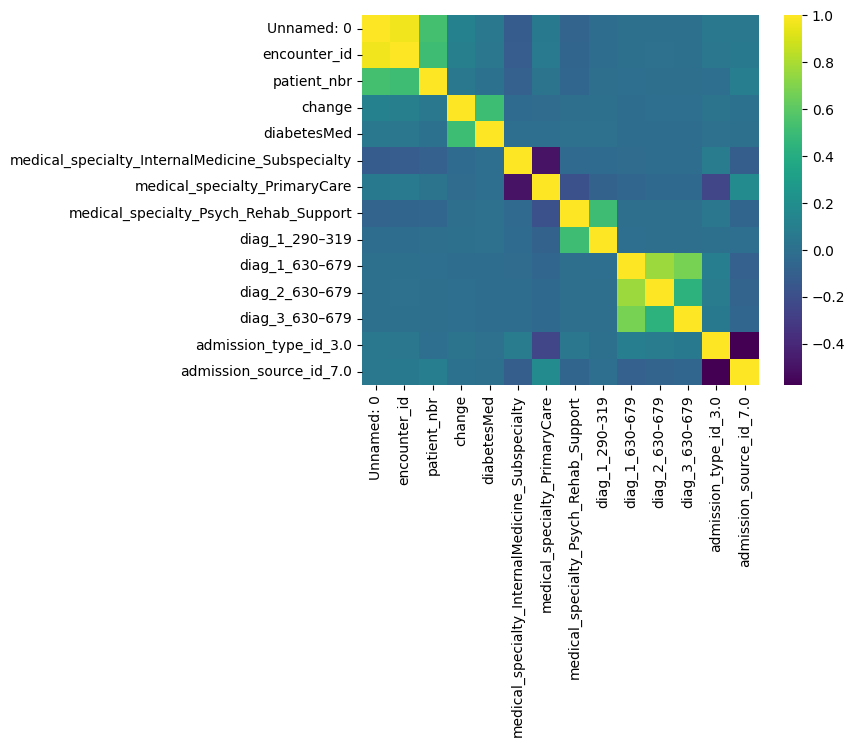

In [18]:
min_thresh = 0.5
corr_matrix = df_6.corr(numeric_only=True)
high_corr_features = corr_matrix.index[(abs(corr_matrix) >= min_thresh).sum() > 1]
high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
sns.heatmap(high_corr_matrix, cmap='viridis')

Drop useless columns

In [19]:
print(df_6.columns)
df_7 = df_6.drop(['Unnamed: 0'], axis = 1)

Index(['Unnamed: 0', 'encounter_id', 'patient_nbr', 'gender', 'age',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient',
       ...
       'admission_source_id_5.0', 'admission_source_id_6.0',
       'admission_source_id_7.0', 'admission_source_id_8.0',
       'admission_source_id_10.0', 'admission_source_id_11.0',
       'admission_source_id_13.0', 'admission_source_id_14.0',
       'admission_source_id_22.0', 'admission_source_id_25.0'],
      dtype='object', length=155)


### Decision Tree
Train a simple decision tree. Simply a benchmark to compare random forest or boosting to. 

In [20]:
#imports
from sklearn import tree

In [21]:
#First split into training and validation set
X_train, X_test, y_train, y_test = train_test_split(df_7.drop(['readmitted'], axis = 1), df_7.loc[:, "readmitted"], test_size=0.2)

In [7]:
simple_tree = tree.DecisionTreeClassifier()
simple_tree.fit(X_train, y_train)

print("Test error: ", 1 - simple_tree.score(X_train, y_train))
print("Validation error: ", 1 - simple_tree.score(X_test, y_test))

Test error:  0.0
Validation error:  0.4981439021727263


See if different criterion leads to better models

In [8]:
simple_tree = tree.DecisionTreeClassifier(criterion="entropy")
simple_tree.fit(X_train, y_train)

print("Test error: ", 1 - simple_tree.score(X_train, y_train))
print("Validation error: ", 1 - simple_tree.score(X_test, y_test))

Test error:  0.0
Validation error:  0.5015285511518724


Try some regularization. See whats the best we can get with a single decision tree

Attempt to regularize with max depth, best is max depth = 6 (val error: 0.41). 

In [9]:
short_tree = tree.DecisionTreeClassifier(max_depth = 6) #6 is best for some reason
short_tree.fit(X_train, y_train)

print("Test error: ", 1 - short_tree.score(X_train, y_train))
print("Validation error: ", 1 - short_tree.score(X_test, y_test))

Test error:  0.41267349974751266
Validation error:  0.41936892673872694


Text(0, 0.5, 'Error')

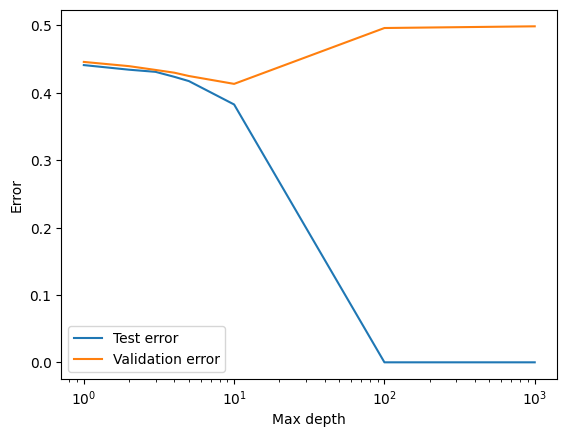

In [10]:
heights = [1,2,3,4, 5, 10, 100, 1000]
test = []
val = []

for height in heights:
    short_tree = tree.DecisionTreeClassifier(max_depth = height) 
    short_tree.fit(X_train, y_train)

    test.append(1 - short_tree.score(X_train, y_train))
    val.append(1 - short_tree.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(heights, test, label = "Test error")
plt.plot(heights, val, label = "Validation error")
plt.legend()
plt.xlabel("Max depth")
plt.ylabel("Error")

Attempt to regularize with min samples, best is min_samples_split = 0.01 (val error: 0.41). 

In [11]:
min_parent = tree.DecisionTreeClassifier(min_samples_split = 0.01) #0.01 is best for some reason
min_parent.fit(X_train, y_train)

print("Test error: ", 1 - min_parent.score(X_train, y_train))
print("Validation error: ", 1 - min_parent.score(X_test, y_test))

Test error:  0.39020895033505754
Validation error:  0.41139862430396335


Text(0, 0.5, 'Error')

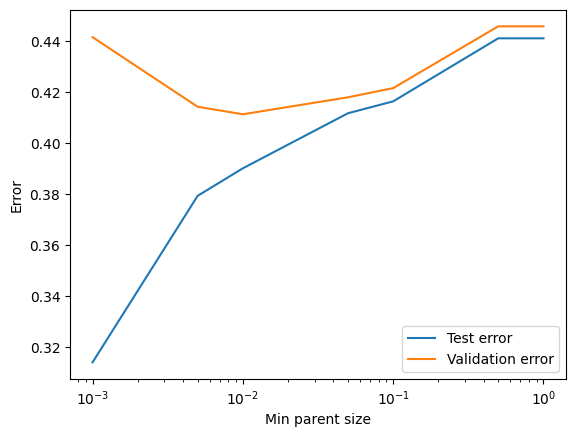

In [12]:
heights = [1.0, .5, .1, 0.05, 0.01, 0.005, 0.001]
test = []
val = []

for height in heights:
    min_parent = tree.DecisionTreeClassifier(min_samples_split = height) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(heights, test, label = "Test error")
plt.plot(heights, val, label = "Validation error")
plt.legend()
plt.xlabel("Min parent size")
plt.ylabel("Error")

Attempt to regularize with maximum leaf nodes. Best is max_leaf_nodes = 250 (val error: 0.41). 

In [13]:
min_parent = tree.DecisionTreeClassifier(max_leaf_nodes = 250)
min_parent.fit(X_train, y_train)

print("Test error: ", 1 - min_parent.score(X_train, y_train))
print("Validation error: ", 1 - min_parent.score(X_test, y_test))

Test error:  0.3871927502013075
Validation error:  0.4103613931651927


Text(0, 0.5, 'Error')

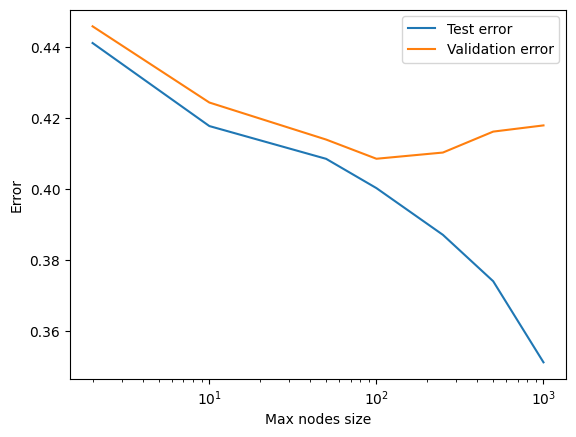

In [14]:
nodes = [2, 10, 50, 100, 250, 500, 1000]
test = []
val = []

for node in nodes:
    min_parent = tree.DecisionTreeClassifier(max_leaf_nodes = node) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(nodes, test, label = "Test error")
plt.plot(nodes, val, label = "Validation error")
plt.legend()
plt.xlabel("Max nodes size")
plt.ylabel("Error")

It looks like the lowest validation error a single decison tree can achieve on this dataset is .41. 

### Random Forest

In [4]:
from sklearn.ensemble import RandomForestClassifier

Default random forest

In [16]:
default = RandomForestClassifier()
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.0
Validation error:  0.40162681515449283


Try different ways of max number of features checked.

In [17]:
default = RandomForestClassifier(max_features="log2")
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.0
Validation error:  0.4049022819085053


0.3986243039633147


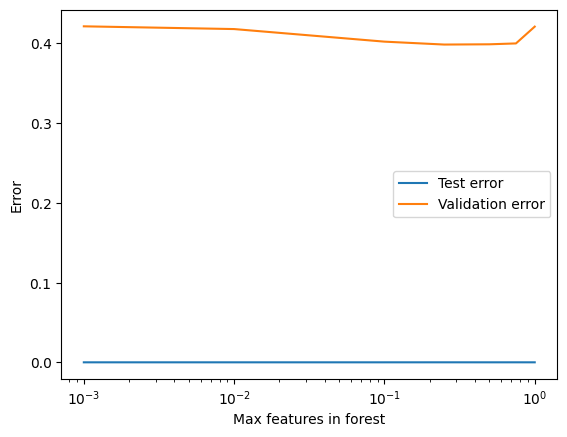

In [18]:
trees = [0.001, 0.01, 0.1, 0.25, .5, .75, 1]
test = []
val = []

last_num = 0
for tree_num in trees:
    min_parent = RandomForestClassifier(max_features = tree_num, n_jobs=-1, warm_start=True) 
    min_parent.fit(X_train, y_train)

    last_num = tree_num

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(trees, test, label = "Test error")
plt.plot(trees, val, label = "Validation error")
plt.legend()
plt.xlabel("Max features in forest")
plt.ylabel("Error")
print(min(val))

Number of trees

In [ ]:
trees = [10, 100, 1000, 2000, 3000, 4000]
test = []
val = []

last_num = 0
for tree_num in trees:
    min_parent = RandomForestClassifier(n_estimators = tree_num-last_num, n_jobs=-1, warm_start=True) 
    min_parent.fit(X_train, y_train)

    last_num = tree_num

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(trees, test, label = "Test error")
plt.plot(trees, val, label = "Validation error")
plt.legend()
plt.xlabel("Trees in forest")
plt.ylabel("Error")
print(min(val))

Experiment combine randomforest with maxleafnode

0.41249044655530076


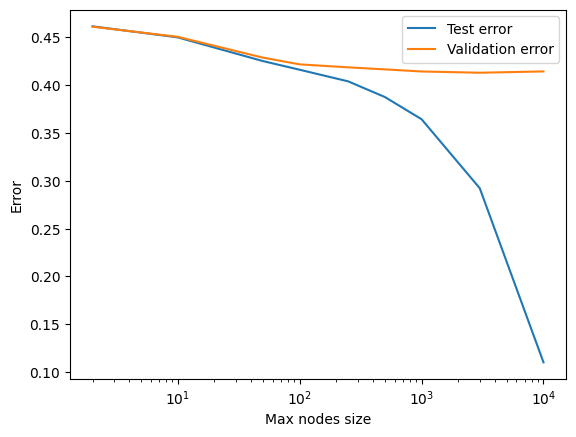

In [ ]:
nodes = [2, 10, 50, 100, 250, 500, 1000, 3000, 10000]
test = []
val = []

for node in nodes:
    min_parent = RandomForestClassifier(n_jobs=-1, max_leaf_nodes = node) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(nodes, test, label = "Test error")
plt.plot(nodes, val, label = "Validation error")
plt.legend()
plt.xlabel("Max nodes size")
plt.ylabel("Error")
print(min(val))

Max samples

In [ ]:
default = RandomForestClassifier(max_samples= .9, n_estimators = 2000, n_jobs=-1)
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.0
Validation error:  0.41243585544273387


In [ ]:
sample = [.1, .25, .33, .5, .75, .8, .9, 1]
test = []
val = []

for sample_size in sample:
    min_parent = RandomForestClassifier(max_samples= sample_size, n_estimators = 2000, n_jobs=-1) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
#plt.xscale("log")
plt.plot(sample, test, label = "Test error")
plt.plot(sample, val, label = "Validation error")
plt.legend()
plt.xlabel("Percentage of data")
plt.ylabel("Error")
print(min(val))

Boosting

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [23]:
default = HistGradientBoostingClassifier()
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.3540827885520874
Validation error:  0.39169123266732175


Text(0, 0.5, 'Error')

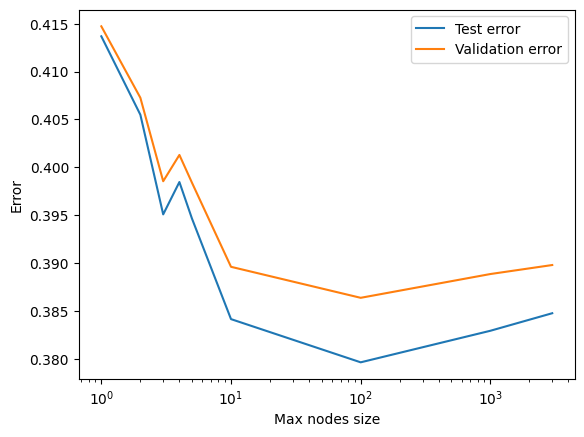

In [ ]:
heights = [1,2,3,4, 5, 10, 100, 1000, 3000]

test = []
val = []

for height in heights:
    min_parent = HistGradientBoostingClassifier(max_iter = 500, max_depth = height) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(heights, test, label = "Test error")
plt.plot(heights, val, label = "Validation error")
plt.legend()
plt.xlabel("Max nodes size")
plt.ylabel("Error")

Best boost results. 

In [ ]:
default = HistGradientBoostingClassifier(max_leaf_nodes=250, max_depth = 5)
default.fit(X_train, y_train)

print("Test error: ", 1 - default.score(X_train, y_train))
print("Validation error: ", 1 - default.score(X_test, y_test))

Test error:  0.3882163475317656
Validation error:  0.41210830876733273


0.41063434872802707


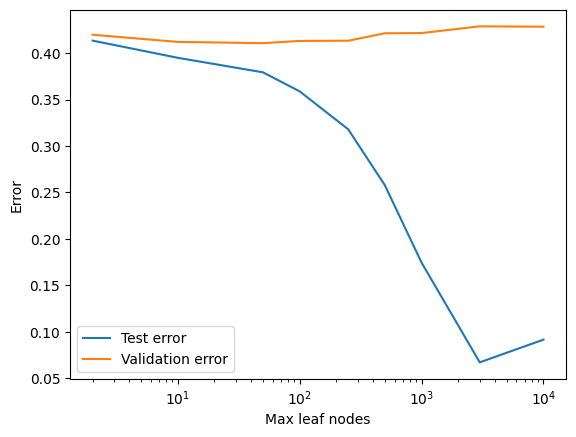

In [ ]:
nodes = [2, 10, 50, 100, 250, 500, 1000, 3000, 10000]
test = []
val = []

for node in nodes:
    min_parent = HistGradientBoostingClassifier(max_leaf_nodes = node, max_iter = 500) 
    min_parent.fit(X_train, y_train)

    test.append(1 - min_parent.score(X_train, y_train))
    val.append(1 - min_parent.score(X_test, y_test))

#axes = plt.subplot()
plt.xscale("log")
plt.plot(nodes, test, label = "Test error")
plt.plot(nodes, val, label = "Validation error")
plt.legend()
plt.xlabel("Max leaf nodes")
plt.ylabel("Error")
print(min(val))

Final models

In [24]:
df = pd.read_csv('clean_testing_data.csv')

df_1 = df.drop(['Unnamed: 0'], axis = 1)
X_test, y_test = (df_1.drop(['readmitted'], axis = 1), df_1.loc[:, "readmitted"])

In [27]:
default = tree.DecisionTreeClassifier(max_leaf_nodes = 250)
default.fit(X_train, y_train)

print("Train accuracy: ", default.score(X_train, y_train))
print("Test accuracy: ", default.score(X_test, y_test))

Train accuracy:  0.614622429064705
Test accuracy:  0.5886803576692542


In [26]:
default = RandomForestClassifier(max_samples= .9, max_depth = 6)
default.fit(X_train, y_train)

print("Train accuracy: ", default.score(X_train, y_train))
print("Test accuracy: ", default.score(X_test, y_test))

Train accuracy:  0.56458899155191
Test accuracy:  0.5584160361599686


In [ ]:
default = HistGradientBoostingClassifier(max_iter = 500, max_depth = 1000)
default.fit(X_train, y_train)

print("Train accuracy: ", default.score(X_train, y_train))
print("Test accuracy: ", default.score(X_test, y_test))

Test accuracy:  0.649233666798597
Validation accuracy:  0.6120664242900659
